# 🐷 Pig Posture Recognition – ConvNeXt Training

**Model:** ConvNeXt-Base (pretrained, `timm`)  
**Input:** 288×288 cropped pig instances  
**Metric:** Macro-averaged F1 score  
**Key changes vs. baseline:** larger model, bigger input, stronger augmentation, more context padding

## ⚙️ Configuration

In [1]:
# ──────────────────────────────────────────────
# CONFIGURATION
# ──────────────────────────────────────────────

TAG = "T2"   # "T1" or "T2"

DATA_ROOT = "/datasets/multi-view-pig-posture-recognition"

if TAG == "T1":
    CSV_PATH = f"{DATA_ROOT}/train1.csv"
    IMG_DIR  = f"{DATA_ROOT}/train1_images"
else:
    CSV_PATH = f"{DATA_ROOT}/train2.csv"
    IMG_DIR  = f"{DATA_ROOT}/train2_images"

OUTPUT_DIR = f"runs/convnext_{TAG.lower()}"

# Model
MODEL_NAME     = "convnext_base"     # stronger than efficientnet_b4
IMG_SIZE       = 288                 # larger input for more detail
BATCH_SIZE     = 32                  # smaller batch for larger model+input
EPOCHS         = 15
LR             = 3e-4
VAL_FRAC       = 0.10
LABEL_SMOOTH   = 0.10
MIXUP_ALPHA    = 0.30
PAD_RATIO      = 0.25               # more context around bbox
NUM_WORKERS    = 8
SEED           = 42

NUM_CLASSES    = 5
CLASS_NAMES    = ["Lateral_lying_left", "Lateral_lying_right",
                  "Sitting", "Standing", "Sternal_lying"]

print(f"Tag: {TAG}  |  Model: {MODEL_NAME}  |  ImgSize: {IMG_SIZE}")
print(f"CSV: {CSV_PATH}")
print(f"Output: {OUTPUT_DIR}")

Tag: T2  |  Model: convnext_base  |  ImgSize: 288
CSV: /datasets/multi-view-pig-posture-recognition/train2.csv
Output: runs/convnext_t2


## 📦 Install Dependencies

In [2]:
!pip install timm tqdm scikit-learn pandas pillow matplotlib -q

## 📚 Imports

In [3]:
import os, ast, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.notebook import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

<jemalloc>: Unsupported system page size


Device: cuda
GPU: Tesla V100-SXM2-32GB


AttributeError: 'torch._C._CudaDeviceProperties' object has no attribute 'total_mem'

## 🔒 Reproducibility

In [4]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 🔍 Load Data

In [5]:
df = pd.read_csv(CSV_PATH)
print(f"Total instances: {len(df)}  |  Unique images: {df['image_id'].nunique()}")

print("\nClass distribution:")
for c in range(NUM_CLASSES):
    cnt = (df["class_id"] == c).sum()
    bar = "█" * int(30 * cnt / len(df))
    print(f"  {c} - {CLASS_NAMES[c]:<22} {bar:<30} {cnt:>5}  ({100*cnt/len(df):.1f}%)")

Total instances: 23450  |  Unique images: 3150

Class distribution:
  0 - Lateral_lying_left     ███                             3083  (13.1%)
  1 - Lateral_lying_right    ████                            3435  (14.6%)
  2 - Sitting                                                 695  (3.0%)
  3 - Standing               ████████████                    9928  (42.3%)
  4 - Sternal_lying          ████████                        6309  (26.9%)


## 🗂️ Dataset & Stronger Augmentations

In [6]:
class PigPostureDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, pad_ratio=0.25):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.pad_ratio = pad_ratio

    def __len__(self): return len(self.df)

    def _crop(self, img, bbox):
        W, H = img.size
        x, y, w, h = [float(v) for v in ast.literal_eval(bbox)]
        px, py = w * self.pad_ratio, h * self.pad_ratio
        x1 = max(0, int(x - px));  y1 = max(0, int(y - py))
        x2 = min(W, int(x+w+px));  y2 = min(H, int(y+h+py))
        return img.crop((x1, y1, x2, y2))

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(os.path.join(self.img_dir, row["image_id"])).convert("RGB")
        crop = self._crop(img, row["bbox"])
        if self.transform: crop = self.transform(crop)
        return crop, int(row["class_id"])


def get_train_transform(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size + 48, size + 48)),
        T.RandomCrop(size),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.3),
        T.RandomRotation(degrees=25),
        T.RandomAffine(degrees=0, scale=(0.85, 1.15)),
        T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.08),
        T.RandomGrayscale(p=0.1),
        T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        T.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    ])

def get_val_transform(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size, size)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

print("Dataset and transforms defined.")

Dataset and transforms defined.


## ✂️ Train / Validation Split

In [7]:
train_df, val_df = train_test_split(
    df, test_size=VAL_FRAC, stratify=df["class_id"], random_state=SEED
)
print(f"Train: {len(train_df)}  |  Val: {len(val_df)}")

train_ds = PigPostureDataset(train_df, IMG_DIR, transform=get_train_transform(), pad_ratio=PAD_RATIO)
val_ds   = PigPostureDataset(val_df,   IMG_DIR, transform=get_val_transform(),   pad_ratio=PAD_RATIO)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print("DataLoaders ready.")

Train: 21105  |  Val: 2345
DataLoaders ready.


## 🧠 Model, Loss & Optimizer

In [8]:
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: {MODEL_NAME}  |  Parameters: {total_params:.1f}M")

# Class-weighted loss
counts  = Counter(train_df["class_id"].tolist())
total   = len(train_df)
weights = torch.tensor(
    [total / (NUM_CLASSES * max(counts.get(c, 1), 1)) for c in range(NUM_CLASSES)],
    dtype=torch.float32
).to(DEVICE)
print("Class weights:", [f"{w:.2f}" for w in weights.cpu()])

criterion       = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTH)
criterion_plain = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = GradScaler()
print("Ready.")

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]

Model: convnext_base  |  Parameters: 87.6M
Class weights: ['1.52', '1.37', '6.74', '0.47', '0.74']
Ready.


## 🛠️ Helper Functions

In [10]:
def mixup_data(x, y, alpha=0.3):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    loss_sum, preds_all, labels_all = 0.0, [], []
    for imgs, labels in tqdm(loader, desc="  Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=MIXUP_ALPHA)
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss   = mixup_loss(criterion_plain, logits, y_a, y_b, lam)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(y_a.cpu().numpy())
    n = len(loader.dataset)
    return loss_sum / n, f1_score(labels_all, preds_all, average="macro", zero_division=0)


@torch.no_grad()
def validate_epoch(model, loader):
    model.eval()
    loss_sum, preds_all, labels_all = 0.0, [], []
    for imgs, labels in tqdm(loader, desc="  Val  ", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)
        loss_sum += loss.item() * imgs.size(0)
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    n = len(loader.dataset)
    return loss_sum / n, f1_score(labels_all, preds_all, average="macro", zero_division=0), preds_all, labels_all

## 🚀 Training Loop (40 Epochs)

In [11]:
best_val_f1 = 0.0
log         = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_f1       = train_one_epoch(model, train_loader, optimizer, scaler)
    val_loss, val_f1, _, _     = validate_epoch(model, val_loader)
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    mark = "★" if val_f1 > best_val_f1 else " "
    print(f"{mark} Epoch {epoch:03d}/{EPOCHS} | "
          f"Train loss={train_loss:.4f} f1={train_f1:.4f} | "
          f"Val loss={val_loss:.4f} f1={val_f1:.4f} | lr={lr:.2e}")

    log.append(dict(epoch=epoch, train_loss=train_loss, train_f1=train_f1,
                    val_loss=val_loss, val_f1=val_f1, lr=lr))

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        ckpt_path   = os.path.join(OUTPUT_DIR, "best_model.pth")
        torch.save({
            "epoch": epoch, "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "val_f1": val_f1, "model_name": MODEL_NAME, "tag": TAG,
        }, ckpt_path)
        print(f"  → Saved best model (val_f1={val_f1:.4f})")

print(f"\n✅ Training complete. Best Val F1: {best_val_f1:.4f}")
pd.DataFrame(log).to_csv(os.path.join(OUTPUT_DIR, "training_log.csv"), index=False)

  Train:   0%|          | 0/659 [00:00<?, ?it/s]

  Val  :   0%|          | 0/74 [00:00<?, ?it/s]

★ Epoch 001/15 | Train loss=1.4461 f1=0.2724 | Val loss=1.3486 f1=0.5905 | lr=2.97e-04
  → Saved best model (val_f1=0.5905)


  Train:   0%|          | 0/659 [00:00<?, ?it/s]

  Val  :   0%|          | 0/74 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/74 [00:00<?, ?it/s]

★ Epoch 014/15 | Train loss=0.4242 f1=0.6235 | Val loss=1.3720 f1=0.9284 | lr=4.27e-06
  → Saved best model (val_f1=0.9284)


  Train:   0%|          | 0/659 [00:00<?, ?it/s]

  Val  :   0%|          | 0/74 [00:00<?, ?it/s]

★ Epoch 015/15 | Train loss=0.4137 f1=0.6180 | Val loss=1.3995 f1=0.9310 | lr=1.00e-06
  → Saved best model (val_f1=0.9310)

✅ Training complete. Best Val F1: 0.9310


## 📈 Training Curves

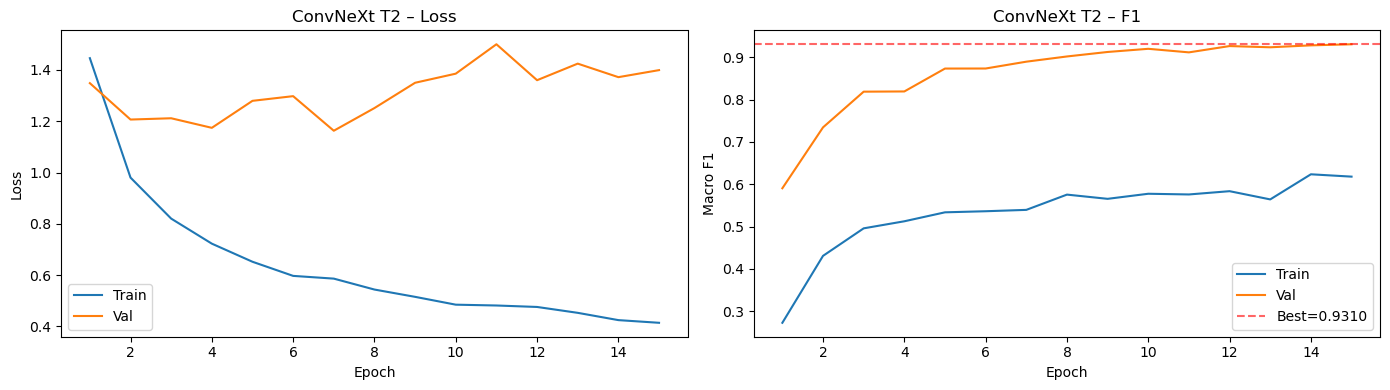

In [12]:
import matplotlib.pyplot as plt

log_df = pd.DataFrame(log)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(log_df["epoch"], log_df["train_loss"], label="Train")
axes[0].plot(log_df["epoch"], log_df["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title(f"ConvNeXt {TAG} – Loss"); axes[0].legend()

axes[1].plot(log_df["epoch"], log_df["train_f1"], label="Train")
axes[1].plot(log_df["epoch"], log_df["val_f1"],   label="Val")
axes[1].axhline(best_val_f1, color="red", ls="--", alpha=0.6, label=f"Best={best_val_f1:.4f}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
axes[1].set_title(f"ConvNeXt {TAG} – F1"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=120)
plt.show()

## 📊 Classification Report (Best Model on Val Set)

In [13]:
best_ckpt = torch.load(os.path.join(OUTPUT_DIR, "best_model.pth"), map_location=DEVICE)
model.load_state_dict(best_ckpt["model"])
_, _, val_preds, val_labels = validate_epoch(model, val_loader)
print(classification_report(val_labels, val_preds, target_names=CLASS_NAMES))

  Val  :   0%|          | 0/74 [00:00<?, ?it/s]

                     precision    recall  f1-score   support

 Lateral_lying_left       0.93      0.94      0.93       308
Lateral_lying_right       0.93      0.97      0.95       344
            Sitting       0.92      0.80      0.85        69
           Standing       0.99      0.99      0.99       993
      Sternal_lying       0.94      0.92      0.93       631

           accuracy                           0.96      2345
          macro avg       0.94      0.92      0.93      2345
       weighted avg       0.96      0.96      0.96      2345

